The notebook contains examples on how to load spikes from .npy files. Loaded spikes are stored in .csv file (all units from all mice).

It plots some summary information about the dataset. The plot is saved in the figures google drive folder.

In [ ]:
import numpy as np
import pandas as pd
import csv
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

#### Parameters

In [2]:
#### Parameters
dataset_folder = Path('D:/PreCosyneBrainhack//')

#### Helper functions

Includes two ways of loading the whole dataset (18 mice):
* store all units from all mice in .csv file. One row corresponds to one unit and has the following format: [mouse_id, cluster_id, brain_area, rec_len_sec, spikes]
* store all units from all mice in pandas dataframe (.pkl file). One row corresponds to one spike and has the following format (df columns): [spikes, brain_area, clusters, num_rec, len_rec]

#### store all units from all mice in .csv file.

In [ ]:
def load_mouse_data(mouse_id: int, dataset_folder: Path, verbose: bool = True):
    """
    Load spikes, cluster IDs, and brain areas for a given mouse folder.

    Parameters
    ----------
    mouse_id : int
        Identifier of the mouse (folder name).
    dataset_folder : Path
        Root dataset folder.
    verbose : bool
        If True, print dataset shapes/info.

    Returns
    -------
    dict
        key is cluster_id, value is { 'spikes': [...], 'brain_area': int}
    """
    mouse_folder = dataset_folder / str(mouse_id)
    if verbose:
        print(f"Loading mouse {mouse_id} from {mouse_folder}")

    # file paths
    brain_areas_file = mouse_folder / "brain_area.npy"
    cluster_ids_file = mouse_folder / "clusters.npy"
    spikes_file = mouse_folder / "spikes.npy"

    # load arrays
    brain_areas = np.load(brain_areas_file, allow_pickle=True).item()
    cluster_ids = np.load(cluster_ids_file)
    spikes = np.load(spikes_file)

    if verbose:
        print(f"brain_areas keys: {list(brain_areas.keys())}")
        print(f"brain_area cluster_id shape: {brain_areas['cluster_id'].shape}")
        print(f"brain_area names shape: {brain_areas['brain_area'].shape}")
        print(f"cluster_ids shape: {cluster_ids.shape}, "
              f"unique clusters: {len(np.unique(cluster_ids))}")
        print(f"spikes shape: {spikes.shape}")

    # build brain area map
    brain_area_map = dict(zip(brain_areas["cluster_id"], brain_areas["brain_area"]))

    # organize spikes per cluster
    cluster_data = {}
    for cid, spike in zip(cluster_ids, spikes):
        cluster_data.setdefault(cid, {"spikes": [], "brain_area": brain_area_map[cid]})
        cluster_data[cid]["spikes"].append(spike)

    return cluster_data


def load_all_mice(dataset_folder: str | Path, n_mice: int = 18, verbose: bool = True):
    """
    Load spikes for all mice.

    Returns
    -------
    dict
        key is mouse_id (folder name), value is cluster_data
    """
    dataset_folder = Path(dataset_folder)
    all_data = {}
    for mouse_id in range(2, n_mice + 1):
        all_data[mouse_id] = load_mouse_data(mouse_id, dataset_folder, verbose=verbose)
    return all_data

#### Loading spikes

In [12]:
spikes_dataset_dict = load_all_mice(dataset_folder, n_mice=18, verbose=False)
export_spikes_to_csv(spikes_dataset_dict, dataset_folder, "output/full_dataset.csv")

#spikes_df = get_spike_df(path_data=dataset_folder)
#spikes_df.to_pickle(dataset_folder / "output/full_dataset.pkl")

CSV file 'D:\PreCosyneBrainhack\output\full_dataset.csv' has been created successfully!


WindowsPath('D:/PreCosyneBrainhack/output/full_dataset.csv')

In [36]:
# collect all trial_data.csv into one DataFrame
all_trials = []
for ii in range(2, 19):
    trialdata_filename = dataset_folder / str(ii) / "trial_data.csv"
    df_mouse = pd.read_csv(trialdata_filename).drop(columns="Unnamed: 0", errors="ignore")
    df_mouse["trial_duration"] = df_mouse["trial_end"] - df_mouse["trial_start"]
    df_mouse.insert(0, "mouse_id", ii)   # put mouse_id as the first column
    all_trials.append(df_mouse)

trails_df = pd.concat(all_trials, ignore_index=True)
trails_df.to_csv(dataset_folder / 'output/trials_info.csv')

trails_df

,mouse_id,variable_A,variable_B,variable_C,trial_start,stim_start,outcome,trial_end,trial_duration
0,2,1,0,0,255.617567,263.146933,298.976567,300.046633,44.429067
1,2,1,1,2,301.153167,301.852800,302.264600,303.336200,2.183033
2,2,1,1,2,304.124500,307.563233,307.832233,308.902933,4.778433
3,2,0,0,2,309.775367,313.379867,313.692667,315.763033,5.987667
4,2,0,0,2,316.599733,317.319400,317.785300,319.846400,3.246667
...,...,...,...,...,...,...,...,...,...
9960,18,0,1,0,2715.423097,2716.084831,2720.247848,2722.301243,6.878146
9961,18,0,1,0,2723.725034,2724.191687,2731.254981,2733.301043,9.576009
9962,18,0,1,0,2734.733566,2735.207785,2735.684571,2737.733933,3.000367
9963,18,0,1,0,2739.147558,2739.891417,2740.525853,2742.584147,3.436589


In [153]:
# decoding performance
score_total = np.zeros((16, 5, 3))

for i in range(16):
    print(i)
    trial_times = all_trials[i]
    spike_info = spikes_dataset_dict[i + 2]

    valueC = trial_times["variable_C"].to_numpy()
    start_time = trial_times["trial_start"].to_numpy()
    stim_start_time = trial_times["stim_start"].to_numpy()
    outcome_time = trial_times["outcome"].to_numpy()
    trial_end_time = trial_times["trial_end"].to_numpy()

    neuronID = np.array(list(spike_info.keys()))
    num_trial = start_time.size
    num_neuron = neuronID.size
    spike_rate = np.zeros((num_trial, num_neuron, 3), dtype=float)

    # Precompute bin durations once (avoid repeated subtraction/division in loops)
    dur1 = stim_start_time - start_time
    dur2 = outcome_time - stim_start_time
    dur3 = trial_end_time - outcome_time

    # Guard against zero/negative durations
    dur1 = np.where(dur1 > 0, dur1, np.nan)
    dur2 = np.where(dur2 > 0, dur2, np.nan)
    dur3 = np.where(dur3 > 0, dur3, np.nan)

    # Vectorized counting per neuron using searchsorted on trial boundaries
    for neuron_idx, cluster_ID in enumerate(neuronID):
        spike_times = np.asarray(spike_info[cluster_ID]["spikes"], dtype=float)
        if spike_times.size == 0:
            continue

        spike_times.sort()

        c_start = np.searchsorted(spike_times, start_time, side="left")
        c_stim = np.searchsorted(spike_times, stim_start_time, side="left")
        c_out = np.searchsorted(spike_times, outcome_time, side="left")
        c_end = np.searchsorted(spike_times, trial_end_time, side="left")

        spike_rate[:, neuron_idx, 0] = (c_stim - c_start) / dur1
        spike_rate[:, neuron_idx, 1] = (c_out - c_stim) / dur2
        spike_rate[:, neuron_idx, 2] = (c_end - c_out) / dur3

    
    # Z-score spike_rate across the 2nd index (axis=1: neurons), per trial and time bin.
    spike_mean = np.nanmean(spike_rate, axis=1, keepdims=True)
    spike_std = np.nanstd(spike_rate, axis=1, keepdims=True)

    # Avoid divide-by-zero/NaN std; keeps NaNs where data were invalid.
    safe_std = np.where((spike_std > 0) & np.isfinite(spike_std), spike_std, 1.0)
    spike_rate = (spike_rate - spike_mean) / safe_std
    
    
    # SVM classification and cross-validated performance on spike_rate (for cell 11 data)
    from sklearn.svm import SVC
    from sklearn.model_selection import cross_val_score, StratifiedKFold

    # Example: Try to classify variable_C from spike_rate during stimulus period (bin 1)
    # We'll flatten spike_rate along the neuron axis.
    y = np.asarray(valueC)  # shape: (num_trial,)

    # Arrange bins for compact processing: (3, num_trial, num_neuron)
    X_bins = np.moveaxis(spike_rate, 2, 0)
    # Valid rows per bin (finite across all neurons): shape (3, num_trial)
    finite_rows_per_bin = np.all(np.isfinite(spike_rate), axis=1).T
    # Reuse the same model/CV config (cross_val_score clones estimator internally)
    clf = SVC(kernel="linear")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    bin_labels = ("start→stim", "stim→outcome", "outcome→trial_end")

    for bin_idx, (X, valid_rows, label) in enumerate(zip(X_bins, finite_rows_per_bin, bin_labels), start=1):
        X_clean = X[valid_rows]
        y_clean = y[valid_rows]

        # Safety check for CV/classification feasibility
        if X_clean.shape[0] < cv.n_splits or np.unique(y_clean).size < 2:
            print(f"Bin {bin_idx} ({label}) skipped: insufficient valid samples/classes.")
            continue

        scores = cross_val_score(clf, X_clean, y_clean, cv=cv)
        score_total[i-2, :, bin_idx-1] = scores
        print(f"Bin {bin_idx} ({label}) - SVM cross-validated accuracy scores: {scores}")
        print(f"Bin {bin_idx} ({label}) - Average accuracy: {scores.mean():.3f}")

0
Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.57647059 0.51764706 0.57058824 0.62941176 0.57647059]
Bin 1 (start→stim) - Average accuracy: 0.574
Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.77647059 0.78823529 0.78235294 0.78823529 0.82941176]
Bin 2 (stim→outcome) - Average accuracy: 0.793
Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.7        0.74705882 0.74705882 0.77058824 0.75294118]
Bin 3 (outcome→trial_end) - Average accuracy: 0.744
1


C:\Users\binw9\AppData\Local\Temp\ipykernel_21272\560793466.py:49: RuntimeWarning: Mean of empty slice
  spike_mean = np.nanmean(spike_rate, axis=1, keepdims=True)
c:\Users\binw9\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.63157895 0.66315789 0.57894737 0.58947368 0.62765957]
Bin 1 (start→stim) - Average accuracy: 0.618
Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.90526316 0.78947368 0.85263158 0.75531915 0.82978723]
Bin 2 (stim→outcome) - Average accuracy: 0.826
Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.71578947 0.78947368 0.86315789 0.73404255 0.81914894]
Bin 3 (outcome→trial_end) - Average accuracy: 0.784
2
Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.48514851 0.61386139 0.58415842 0.48514851 0.48514851]
Bin 1 (start→stim) - Average accuracy: 0.531
Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.87128713 0.82178218 0.83168317 0.81188119 0.84158416]
Bin 2 (stim→outcome) - Average accuracy: 0.836
Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.63366337 0.66336634 0.68316832 0.73267327 0.62376238]
Bin 3 (outcome→trial_end) - Average accuracy: 0.667
3


C:\Users\binw9\AppData\Local\Temp\ipykernel_21272\560793466.py:49: RuntimeWarning: Mean of empty slice
  spike_mean = np.nanmean(spike_rate, axis=1, keepdims=True)
c:\Users\binw9\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.6        0.57647059 0.6        0.65882353 0.55952381]
Bin 1 (start→stim) - Average accuracy: 0.599
Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.88235294 0.83529412 0.87058824 0.72941176 0.67857143]
Bin 2 (stim→outcome) - Average accuracy: 0.799
Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.81176471 0.65882353 0.76470588 0.78571429 0.66666667]
Bin 3 (outcome→trial_end) - Average accuracy: 0.738
4
Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.67368421 0.60638298 0.61702128 0.5        0.59574468]
Bin 1 (start→stim) - Average accuracy: 0.599
Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.61052632 0.65957447 0.71276596 0.71276596 0.67021277]
Bin 2 (stim→outcome) - Average accuracy: 0.673
Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.67368421 0.71276596 0.65957447 0.79787234 0.70212766]
Bin 3 (outcome→trial_end) - Average accuracy: 0.709
5


...

Bin 1 (start→stim) - SVM cross-validated accuracy scores: [0.60301508 0.61809045 0.54773869 0.6080402  0.57575758]
Bin 1 (start→stim) - Average accuracy: 0.591


c:\Users\binw9\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Bin 2 (stim→outcome) - SVM cross-validated accuracy scores: [0.71859296 0.73366834 0.72361809 0.75757576 0.75252525]
Bin 2 (stim→outcome) - Average accuracy: 0.737


c:\Users\binw9\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Bin 3 (outcome→trial_end) - SVM cross-validated accuracy scores: [0.83417085 0.85427136 0.76884422 0.8030303  0.82323232]
Bin 3 (outcome→trial_end) - Average accuracy: 0.817


Decoding performance by interval:
         interval  n_mice  mean_acc  sem_acc
       start→stim      16    0.5872   0.0136
     stim→outcome      16    0.7510   0.0134
outcome→trial_end      16    0.7187   0.0126

Friedman test across intervals (n=16 mice): stat=26.0000, p=2.26e-06

Pairwise interval comparisons (Wilcoxon, Bonferroni-corrected):
                       comparison  n_mice  stat         p    p_bonf  significant_0.05
       start→stim vs stim→outcome      16     0 3.052e-05 9.155e-05              True
  start→stim vs outcome→trial_end      16     0 3.052e-05 9.155e-05              True
stim→outcome vs outcome→trial_end      16    26   0.02899   0.08698             False


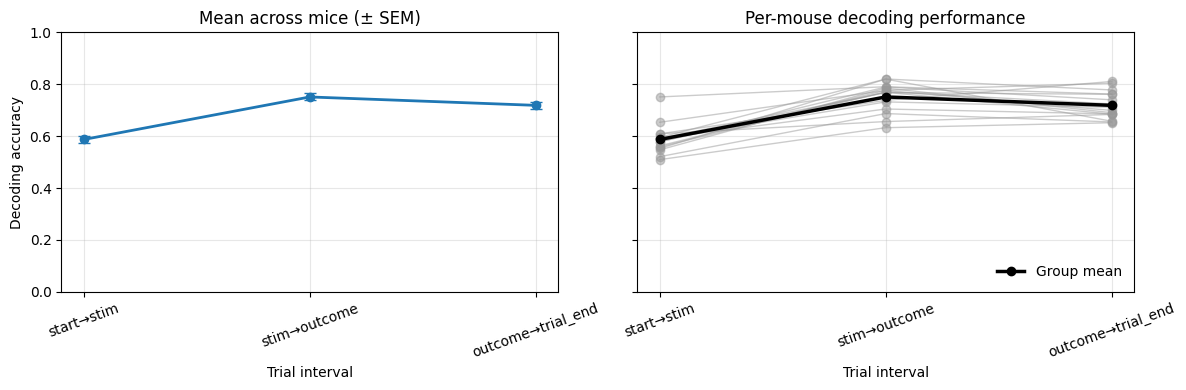

In [152]:
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon

# score_total expected shape: (n_mice, n_folds, n_bins)
scores = np.asarray(score_total, dtype=float)
if scores.ndim != 3:
    raise ValueError(f"`score_total` must be 3D (n_mice, n_folds, n_bins), got shape={scores.shape}")

# Trial-interval labels
bin_labels = ["start→stim", "stim→outcome", "outcome→trial_end"]
n_bins = scores.shape[-1]
if len(bin_labels) != n_bins:
    bin_labels = [f"Bin {i+1}" for i in range(n_bins)]
x = np.arange(n_bins)

# Decoding performance per mouse (average CV accuracy across folds)
per_mouse_bin_mean = np.nanmean(scores, axis=1)  # shape: (n_mice, n_bins)

# Group summary across mice
n_mice_valid = np.sum(np.isfinite(per_mouse_bin_mean), axis=0)
group_mean = np.nanmean(per_mouse_bin_mean, axis=0)
group_std = np.nanstd(per_mouse_bin_mean, axis=0)
group_sem = np.where(n_mice_valid > 0, group_std / np.sqrt(n_mice_valid), np.nan)

# Print summary table
summary_df = pd.DataFrame(
    {
        "interval": bin_labels,
        "n_mice": n_mice_valid,
        "mean_acc": group_mean,
        "sem_acc": group_sem,
    }
)
print("Decoding performance by interval:")
print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# ---------- Significance tests across intervals ----------
# Omnibus test (repeated measures across intervals): Friedman test
valid_all_bins = np.all(np.isfinite(per_mouse_bin_mean), axis=1)
if valid_all_bins.sum() >= 3 and n_bins >= 2:
    friedman_stat, friedman_p = friedmanchisquare(
        *[per_mouse_bin_mean[valid_all_bins, b] for b in range(n_bins)]
    )
    print(f"\nFriedman test across intervals (n={valid_all_bins.sum()} mice): "
          f"stat={friedman_stat:.4f}, p={friedman_p:.4g}")
else:
    friedman_p = np.nan
    print("\nFriedman test skipped (need >=3 mice with valid scores in all intervals).")

# Pairwise post-hoc tests: Wilcoxon signed-rank (paired), Bonferroni corrected
pairwise_rows = []
pairs = list(combinations(range(n_bins), 2))
for a, b in pairs:
    valid_pair = np.isfinite(per_mouse_bin_mean[:, a]) & np.isfinite(per_mouse_bin_mean[:, b])
    n_pair = int(valid_pair.sum())

    if n_pair < 3:
        pairwise_rows.append(
            {"comparison": f"{bin_labels[a]} vs {bin_labels[b]}", "n_mice": n_pair, "stat": np.nan, "p": np.nan}
        )
        continue

    try:
        stat, p = wilcoxon(
            per_mouse_bin_mean[valid_pair, a],
            per_mouse_bin_mean[valid_pair, b],
            alternative="two-sided",
            zero_method="zsplit",
            method="auto",
        )
    except ValueError:
        stat, p = np.nan, np.nan

    pairwise_rows.append(
        {"comparison": f"{bin_labels[a]} vs {bin_labels[b]}", "n_mice": n_pair, "stat": stat, "p": p}
    )

pairwise_df = pd.DataFrame(pairwise_rows)
m_tests = max(len(pairwise_df), 1)
pairwise_df["p_bonf"] = np.minimum(pairwise_df["p"] * m_tests, 1.0)
pairwise_df["significant_0.05"] = pairwise_df["p_bonf"] < 0.05

print("\nPairwise interval comparisons (Wilcoxon, Bonferroni-corrected):")
print(pairwise_df.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Panel 1: group mean ± SEM
axes[0].errorbar(x, group_mean, yerr=group_sem, fmt="o-", capsize=4, lw=2, color="tab:blue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bin_labels, rotation=20)
axes[0].set_xlabel("Trial interval")
axes[0].set_ylabel("Decoding accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_title("Mean across mice (± SEM)")
axes[0].grid(alpha=0.3)

# Panel 2: individual mice + group mean
for mouse_idx in range(per_mouse_bin_mean.shape[0]):
    axes[1].plot(x, per_mouse_bin_mean[mouse_idx], marker="o", lw=1, alpha=0.5, color="0.6")
axes[1].plot(x, group_mean, "k-o", lw=2.5, label="Group mean")
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=20)
axes[1].set_xlabel("Trial interval")
axes[1].set_title("Per-mouse decoding performance")
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=False, loc="lower right")

plt.tight_layout()

Decoding performance by interval:
         interval  n_mice  mean_acc  sem_acc
       start→stim      16    0.5905   0.0141
     stim→outcome      16    0.7577   0.0129
outcome→trial_end      16    0.7323   0.0112

Friedman test across intervals (n=16 mice): stat=24.5000, p=4.785e-06

Pairwise interval comparisons (Wilcoxon, Bonferroni-corrected):
                       comparison  n_mice  stat         p    p_bonf  significant_0.05
       start→stim vs stim→outcome      16     0 3.052e-05 9.155e-05              True
  start→stim vs outcome→trial_end      16     0 3.052e-05 9.155e-05              True
stim→outcome vs outcome→trial_end      16    36    0.1046    0.3138             False


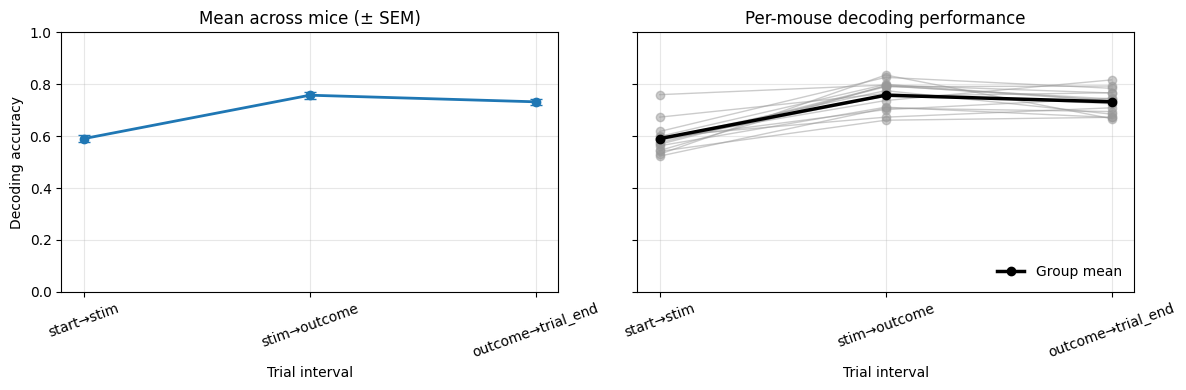

In [154]:
from itertools import combinations
from scipy.stats import friedmanchisquare, wilcoxon

# score_total expected shape: (n_mice, n_folds, n_bins)
scores = np.asarray(score_total, dtype=float)
if scores.ndim != 3:
    raise ValueError(f"`score_total` must be 3D (n_mice, n_folds, n_bins), got shape={scores.shape}")

# Trial-interval labels
bin_labels = ["start→stim", "stim→outcome", "outcome→trial_end"]
n_bins = scores.shape[-1]
if len(bin_labels) != n_bins:
    bin_labels = [f"Bin {i+1}" for i in range(n_bins)]
x = np.arange(n_bins)

# Decoding performance per mouse (average CV accuracy across folds)
per_mouse_bin_mean = np.nanmean(scores, axis=1)  # shape: (n_mice, n_bins)

# Group summary across mice
n_mice_valid = np.sum(np.isfinite(per_mouse_bin_mean), axis=0)
group_mean = np.nanmean(per_mouse_bin_mean, axis=0)
group_std = np.nanstd(per_mouse_bin_mean, axis=0)
group_sem = np.where(n_mice_valid > 0, group_std / np.sqrt(n_mice_valid), np.nan)

# Print summary table
summary_df = pd.DataFrame(
    {
        "interval": bin_labels,
        "n_mice": n_mice_valid,
        "mean_acc": group_mean,
        "sem_acc": group_sem,
    }
)
print("Decoding performance by interval:")
print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

# ---------- Significance tests across intervals ----------
# Omnibus test (repeated measures across intervals): Friedman test
valid_all_bins = np.all(np.isfinite(per_mouse_bin_mean), axis=1)
if valid_all_bins.sum() >= 3 and n_bins >= 2:
    friedman_stat, friedman_p = friedmanchisquare(
        *[per_mouse_bin_mean[valid_all_bins, b] for b in range(n_bins)]
    )
    print(f"\nFriedman test across intervals (n={valid_all_bins.sum()} mice): "
          f"stat={friedman_stat:.4f}, p={friedman_p:.4g}")
else:
    friedman_p = np.nan
    print("\nFriedman test skipped (need >=3 mice with valid scores in all intervals).")

# Pairwise post-hoc tests: Wilcoxon signed-rank (paired), Bonferroni corrected
pairwise_rows = []
pairs = list(combinations(range(n_bins), 2))
for a, b in pairs:
    valid_pair = np.isfinite(per_mouse_bin_mean[:, a]) & np.isfinite(per_mouse_bin_mean[:, b])
    n_pair = int(valid_pair.sum())

    if n_pair < 3:
        pairwise_rows.append(
            {"comparison": f"{bin_labels[a]} vs {bin_labels[b]}", "n_mice": n_pair, "stat": np.nan, "p": np.nan}
        )
        continue

    try:
        stat, p = wilcoxon(
            per_mouse_bin_mean[valid_pair, a],
            per_mouse_bin_mean[valid_pair, b],
            alternative="two-sided",
            zero_method="zsplit",
            method="auto",
        )
    except ValueError:
        stat, p = np.nan, np.nan

    pairwise_rows.append(
        {"comparison": f"{bin_labels[a]} vs {bin_labels[b]}", "n_mice": n_pair, "stat": stat, "p": p}
    )

pairwise_df = pd.DataFrame(pairwise_rows)
m_tests = max(len(pairwise_df), 1)
pairwise_df["p_bonf"] = np.minimum(pairwise_df["p"] * m_tests, 1.0)
pairwise_df["significant_0.05"] = pairwise_df["p_bonf"] < 0.05

print("\nPairwise interval comparisons (Wilcoxon, Bonferroni-corrected):")
print(pairwise_df.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

# ---------- Visualization ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# Panel 1: group mean ± SEM
axes[0].errorbar(x, group_mean, yerr=group_sem, fmt="o-", capsize=4, lw=2, color="tab:blue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(bin_labels, rotation=20)
axes[0].set_xlabel("Trial interval")
axes[0].set_ylabel("Decoding accuracy")
axes[0].set_ylim(0, 1)
axes[0].set_title("Mean across mice (± SEM)")
axes[0].grid(alpha=0.3)

# Panel 2: individual mice + group mean
for mouse_idx in range(per_mouse_bin_mean.shape[0]):
    axes[1].plot(x, per_mouse_bin_mean[mouse_idx], marker="o", lw=1, alpha=0.5, color="0.6")
axes[1].plot(x, group_mean, "k-o", lw=2.5, label="Group mean")
axes[1].set_xticks(x)
axes[1].set_xticklabels(bin_labels, rotation=20)
axes[1].set_xlabel("Trial interval")
axes[1].set_title("Per-mouse decoding performance")
axes[1].grid(alpha=0.3)
axes[1].legend(frameon=False, loc="lower right")

plt.tight_layout()